# Úvod do DEAP (Distributed Evolutionary Algorithms in Python)

instalace v terminálu pomocí 

conda install -c conda-forge deap 

In [1]:
import numpy as np

import random

from deap import base, creator, tools, algorithms



## Vytváření nových typů
---

### Fitness
params: název, objekt fitness, -1.0 minimalizace / 1.0 maximalizace

In [2]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

### Individua
params: název, třída datové struktury, fitness dle existující zaregistrované

budeme pracovat s listy (jde i numpy pole ale pozor na views!)

existuje celá řada typů: permutace, stromy, atd.

In [3]:
creator.create("Individual", list, fitness=creator.FitnessMax)

In [5]:
IND_SIZE = 10

In [6]:
toolbox = base.Toolbox()

toolbox.register("attr_float", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_float, n=IND_SIZE)
#toolbox.register("individual", initind, IND_LEN)  # název, funkce, poporade parametry krmici funkci

In [7]:
ind1 = toolbox.individual()
print(ind1)
ind1[1]

[0, 1, 1, 1, 0, 1, 0, 1, 0, 1]


1

In [8]:
ind1.fitness.values


()

### Populace

In [9]:
toolbox.register("population", tools.initRepeat, list, toolbox.individual) 
# init repeat opakuje dle parametru za ni, tedy dela list individui dle zakladni inicializace individua


In [10]:
pop = toolbox.population(n=10)
print(pop)

[[1, 1, 0, 0, 0, 1, 1, 1, 1, 1], [1, 0, 0, 1, 0, 0, 0, 1, 1, 0], [0, 0, 1, 1, 1, 0, 1, 1, 1, 1], [1, 0, 1, 1, 1, 1, 0, 1, 0, 1], [0, 0, 0, 0, 0, 1, 1, 1, 0, 1], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 0, 0, 1, 0, 0, 0, 0, 0], [1, 0, 0, 1, 0, 1, 1, 0, 0, 0], [1, 0, 0, 0, 0, 0, 1, 1, 0, 1], [1, 1, 0, 1, 1, 1, 0, 1, 0, 0]]


## Fitness
---
Tuto funkci si musíme napsat sami !!!

In [11]:
def evaluate(individual):
    return sum(individual),    # !!!! vracíme n-tici, proto ta čárka

In [12]:
toolbox.register("evaluate", evaluate)

## Operátory
---

sada operátorů lze nalézt v [dokumentaci](https://deap.readthedocs.io/en/master/api/tools.html#module-deap.tools)

In [14]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=1, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

## Jednoduchý algoritmus
---

In [15]:
# hlavní parametry vystrčené kvůli experimentování

NGEN = 50            # počet generací
CXPB = 0.7           # pravděpodobnost crossoveru na páru
MUTPB = 0.2         # pravděpodobnost mutace jedince

finalpop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN)


gen	nevals
0  	10    
1  	9     
2  	6     
3  	9     
4  	8     
5  	6     
6  	8     
7  	6     
8  	8     
9  	8     
10 	5     
11 	10    
12 	8     
13 	4     
14 	8     
15 	5     
16 	6     
17 	6     
18 	7     
19 	6     
20 	8     
21 	10    
22 	7     
23 	6     
24 	6     
25 	7     
26 	4     
27 	8     
28 	4     
29 	2     
30 	8     
31 	10    
32 	7     
33 	5     
34 	6     
35 	10    
36 	6     
37 	7     
38 	8     
39 	6     
40 	8     
41 	6     
42 	8     
43 	8     
44 	7     
45 	6     
46 	8     
47 	8     
48 	10    
49 	5     
50 	4     


## Statistika
---

In [16]:
import numpy as np

s = tools.Statistics(key=lambda ind: ind.fitness.values)
s.register("mean", np.mean)
s.register("max", np.max)


hof = tools.HallOfFame(1)  # pamatuje si 1 nejlepšího jedince za historii evoluce (i když zanikne)

pop = toolbox.population(n=10)


finalpop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=s, halloffame=hof)

gen	nevals	mean	max
0  	10    	4.6 	7  
1  	10    	5.9 	7  
2  	8     	6.5 	8  
3  	10    	7.1 	8  
4  	5     	7.5 	8  
5  	6     	7.8 	8  
6  	8     	7.9 	8  
7  	9     	8   	8  
8  	10    	7.8 	8  
9  	8     	8   	8  
10 	8     	8   	8  
11 	6     	8   	8  
12 	6     	8   	8  
13 	7     	8   	9  
14 	10    	8.2 	9  
15 	8     	8.3 	9  
16 	8     	8.5 	9  
17 	7     	8.8 	9  
18 	6     	8.9 	9  
19 	6     	9   	9  
20 	8     	9   	9  
21 	8     	8.9 	9  
22 	9     	8.9 	9  
23 	10    	9   	9  
24 	6     	9   	9  
25 	9     	8.9 	9  
26 	7     	8.9 	9  
27 	8     	9   	9  
28 	7     	8.9 	9  
29 	8     	9   	9  
30 	9     	8.9 	9  
31 	10    	9   	9  
32 	8     	9   	9  
33 	8     	9   	9  
34 	5     	9   	9  
35 	10    	9   	9  
36 	8     	9   	9  
37 	9     	9   	9  
38 	6     	9   	9  
39 	8     	8.8 	9  
40 	9     	8.9 	9  
41 	9     	8.8 	9  
42 	6     	9   	9  
43 	5     	9   	9  
44 	4     	8.8 	9  
45 	8     	9   	9  
46 	6     	9   	9  
47 	5     	9   	9  
48 	7     	8.9 	9  


In [17]:
mean, maximum = logbook.select("mean", "max")


print(hof)

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]]


## Kreslení statistiky
---

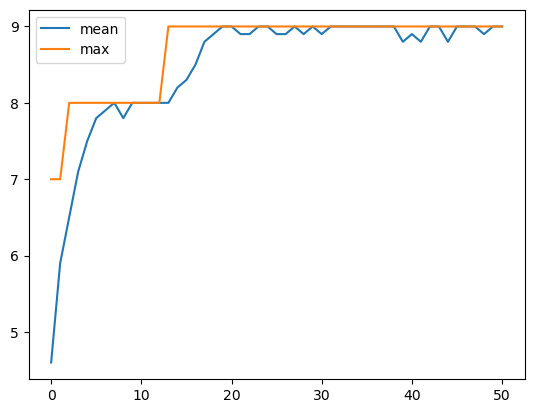

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(range(NGEN+1), mean, label="mean")     # 0.tá generace zvlášť
ax.plot(range(NGEN+1), maximum, label="max")

ax.legend()

## Aplikace na barvení grafu
---

### Načtení dat

In [22]:
import numpy as np
import networkx as nx



# funkce pro nacitani grafu z Dimacs formatu
def readdimacs(filename):

    file = open(filename, 'r')
    lines = file.readlines()
    
    Gd = nx.Graph()

    for line in lines:
        if line[0] == "e":
            vs = [int(s) for s in line.split() if s.isdigit()]
            Gd.add_edge(vs[0]-1, vs[1]-1)   # dimacs cisluje vrcholy od 1
    return Gd

Gd = nx.Graph()
Gd = readdimacs('dsjc125.1.col') 




### Definice GA

In [31]:

COLNUM = 5 # počet barev

N = Gd.number_of_nodes()

creator.create("FitnessMax", base.Fitness, weights=(-1.0,))  # minimalizujeme počet kolizí

creator.create("Individual", list, fitness=creator.FitnessMax)


toolbox = base.Toolbox()

toolbox.register("attr_float", random.randint, 0, COLNUM-1) #Added -1 to COLNUM, according to the lecture
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_float, n=N)


toolbox.register("population", tools.initRepeat, list, toolbox.individual) 


# vrací celkový počet kolizí
def evaluate(individual):
    
    collisions = 0
    
    for i in range(N-1):
        for j in range(i, N):
            if Gd.has_edge(i, j):
                if individual[i] == individual[j]:
                    collisions += 1
    return collisions, # !!!! vracíme n-tici, proto ta čárka
   

toolbox.register("evaluate", evaluate)


toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=COLNUM-1, indpb=0.01) #Added -1 to COLNUM, according to the lecture
toolbox.register("select", tools.selTournament, tournsize=2)



NGEN = 3000          # počet generací
CXPB = 0.5           # pravděpodobnost crossoveru na páru
MUTPB = 0.7         # pravděpodobnost mutace



s = tools.Statistics(key=lambda ind: ind.fitness.values)
s.register("mean", np.mean)
s.register("min", np.min)

pop = toolbox.population(n=1000)


finalpop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=s)

gen	nevals	mean   	min
0  	1000  	147.057	108
1  	862   	141.856	110
2  	852   	137.891	112
3  	868   	135.634	111
4  	858   	133.826	110
5  	870   	132.034	110
6  	847   	130.288	110
7  	851   	128.789	109
8  	862   	127.658	106
9  	873   	126.761	103
10 	858   	125.775	103
11 	858   	125.248	102
12 	880   	124.186	104
13 	869   	123.241	100
14 	866   	121.937	97 
15 	836   	120.403	97 
16 	835   	119.376	96 
17 	847   	117.931	95 
18 	836   	117.211	94 
19 	850   	116.174	96 
20 	863   	115.368	98 
21 	841   	114.565	93 
22 	836   	114.169	92 
23 	863   	112.799	89 
24 	859   	111.853	89 
25 	853   	111.198	83 
26 	856   	109.808	87 
27 	867   	108.16 	89 
28 	835   	105.475	82 
29 	845   	103.461	81 
30 	871   	101.58 	83 
31 	876   	98.792 	77 
32 	848   	96.559 	77 
33 	841   	94.234 	76 
34 	856   	92.293 	76 
35 	860   	90.339 	74 
36 	852   	88.513 	72 
37 	857   	86.657 	70 
38 	855   	85.199 	69 
39 	849   	83.962 	72 
40 	867   	82.7   	70 
41 	869   	81.4   	67 
42 	862   	

356	866   	19.532 	15 
357	834   	19.464 	15 
358	848   	19.576 	14 
359	854   	19.615 	14 
360	830   	19.534 	14 
361	832   	19.308 	14 
362	868   	19.314 	14 
363	851   	19.283 	14 
364	837   	19.188 	14 
365	843   	19     	14 
366	849   	19.06  	14 
367	820   	18.879 	14 
368	834   	18.975 	14 
369	834   	19.046 	14 
370	836   	19.107 	14 
371	833   	18.953 	14 
372	857   	18.92  	14 
373	846   	18.749 	14 
374	849   	18.866 	14 
375	838   	18.842 	14 
376	840   	18.89  	14 
377	845   	18.927 	14 
378	856   	18.643 	14 
379	837   	18.574 	14 
380	824   	18.571 	14 
381	840   	18.598 	14 
382	862   	18.697 	14 
383	830   	18.809 	14 
384	852   	18.743 	14 
385	833   	18.425 	14 
386	857   	18.535 	14 
387	839   	18.197 	14 
388	868   	18.104 	14 
389	841   	18.133 	14 
390	834   	18.058 	14 
391	862   	18.337 	14 
392	852   	17.968 	14 
393	851   	17.913 	14 
394	848   	18.039 	14 
395	865   	18.057 	14 
396	847   	17.943 	14 
397	855   	17.93  	14 
398	866   	17.797 	14 
399	846   	

713	846   	14.72  	11 
714	843   	14.623 	11 
715	842   	14.547 	11 
716	872   	14.488 	11 
717	841   	14.373 	11 
718	852   	14.501 	11 
719	871   	14.568 	11 
720	862   	14.77  	11 
721	847   	14.862 	11 
722	839   	14.985 	11 
723	860   	15.013 	11 
724	864   	15.109 	11 
725	861   	15.066 	11 
726	832   	15     	11 
727	848   	15.077 	11 
728	857   	14.999 	11 
729	850   	14.851 	11 
730	844   	14.666 	11 
731	862   	14.707 	11 
732	872   	14.625 	11 
733	859   	14.41  	11 
734	844   	14.327 	11 
735	854   	14.158 	11 
736	847   	14.319 	11 
737	829   	14.341 	11 
738	852   	14.471 	11 
739	855   	14.248 	11 
740	841   	14.267 	11 
741	842   	14.354 	11 
742	867   	14.474 	11 
743	860   	14.323 	11 
744	857   	14.285 	11 
745	865   	14.349 	11 
746	838   	14.484 	11 
747	825   	14.39  	11 
748	851   	14.438 	11 
749	851   	14.655 	11 
750	859   	14.603 	11 
751	848   	14.679 	11 
752	857   	14.576 	11 
753	851   	14.471 	11 
754	849   	14.559 	11 
755	832   	14.661 	11 
756	842   	

1067	862   	14.591 	11 
1068	865   	14.526 	11 
1069	856   	14.519 	11 
1070	824   	14.311 	11 
1071	863   	14.453 	11 
1072	856   	14.578 	11 
1073	840   	14.666 	11 
1074	886   	14.68  	11 
1075	838   	14.624 	11 
1076	861   	14.571 	11 
1077	842   	14.492 	11 
1078	867   	14.677 	11 
1079	874   	14.76  	11 
1080	866   	14.705 	11 
1081	852   	14.676 	11 
1082	845   	14.827 	11 
1083	854   	14.667 	11 
1084	828   	14.603 	11 
1085	861   	14.906 	11 
1086	840   	14.879 	11 
1087	839   	14.932 	11 
1088	853   	14.985 	11 
1089	849   	15.064 	11 
1090	849   	15.005 	11 
1091	860   	15.055 	11 
1092	866   	14.896 	11 
1093	833   	15.204 	11 
1094	870   	15.038 	11 
1095	845   	14.931 	11 
1096	837   	14.889 	11 
1097	837   	14.871 	11 
1098	863   	14.877 	11 
1099	833   	14.926 	11 
1100	831   	14.847 	11 
1101	841   	14.797 	11 
1102	854   	14.545 	11 
1103	824   	14.455 	11 
1104	848   	14.333 	11 
1105	837   	14.553 	11 
1106	857   	14.553 	11 
1107	854   	14.515 	11 
1108	837   	14.4

1409	866   	14.671 	10 
1410	840   	14.471 	10 
1411	857   	14.462 	10 
1412	836   	14.444 	10 
1413	853   	14.552 	10 
1414	832   	14.494 	10 
1415	838   	14.388 	10 
1416	859   	14.42  	10 
1417	864   	14.251 	10 
1418	841   	14.308 	10 
1419	851   	14.293 	10 
1420	873   	14.273 	10 
1421	866   	14.32  	10 
1422	850   	14.284 	10 
1423	855   	14.258 	10 
1424	847   	14.361 	10 
1425	854   	14.2   	10 
1426	841   	14.345 	10 
1427	843   	14.355 	10 
1428	877   	14.417 	10 
1429	857   	14.299 	10 
1430	859   	14.269 	10 
1431	848   	14.191 	10 
1432	877   	14.058 	10 
1433	855   	13.939 	10 
1434	857   	14     	10 
1435	843   	14.093 	10 
1436	866   	14.046 	10 
1437	835   	13.78  	10 
1438	862   	13.951 	10 
1439	860   	13.917 	10 
1440	842   	13.906 	10 
1441	836   	13.676 	10 
1442	837   	13.871 	10 
1443	851   	13.808 	10 
1444	836   	13.862 	10 
1445	870   	13.895 	10 
1446	835   	14.019 	10 
1447	860   	13.856 	10 
1448	856   	13.576 	10 
1449	849   	13.502 	10 
1450	847   	13.4

1751	824   	13.541 	10 
1752	841   	13.638 	10 
1753	834   	13.629 	10 
1754	836   	13.632 	10 
1755	854   	13.708 	10 
1756	854   	13.647 	10 
1757	849   	13.614 	10 
1758	848   	13.552 	10 
1759	877   	13.692 	10 
1760	857   	13.849 	10 
1761	837   	13.833 	10 
1762	852   	13.678 	10 
1763	869   	13.832 	10 
1764	851   	13.781 	10 
1765	851   	13.661 	10 
1766	839   	13.63  	10 
1767	860   	13.562 	10 
1768	840   	13.405 	10 
1769	868   	13.655 	10 
1770	854   	13.79  	10 
1771	829   	13.64  	10 
1772	842   	13.496 	10 
1773	872   	13.761 	10 
1774	841   	13.916 	10 
1775	841   	13.939 	10 
1776	841   	13.594 	10 
1777	842   	13.618 	10 
1778	833   	13.569 	10 
1779	837   	13.687 	10 
1780	847   	13.871 	10 
1781	849   	13.902 	10 
1782	847   	14.081 	10 
1783	843   	13.929 	10 
1784	839   	13.769 	10 
1785	862   	13.777 	10 
1786	816   	13.648 	10 
1787	839   	13.461 	10 
1788	863   	13.391 	10 
1789	858   	13.594 	10 
1790	816   	13.756 	10 
1791	862   	13.607 	10 
1792	832   	13.6

2093	860   	13.964 	9  
2094	843   	13.799 	9  
2095	862   	13.949 	9  
2096	855   	13.867 	9  
2097	849   	14.034 	9  
2098	841   	14.056 	9  
2099	868   	14.152 	9  
2100	839   	14.072 	9  
2101	849   	13.944 	9  
2102	848   	13.728 	9  
2103	848   	13.733 	9  
2104	869   	13.758 	9  
2105	833   	13.799 	9  
2106	849   	13.828 	9  
2107	840   	13.619 	9  
2108	851   	13.844 	9  
2109	860   	13.773 	9  
2110	859   	13.626 	9  
2111	859   	13.545 	9  
2112	846   	13.515 	9  
2113	838   	13.525 	9  
2114	855   	13.475 	9  
2115	831   	13.395 	9  
2116	847   	13.384 	9  
2117	843   	13.364 	9  
2118	829   	13.513 	9  
2119	841   	13.562 	9  
2120	839   	13.587 	9  
2121	846   	13.593 	9  
2122	840   	13.492 	9  
2123	854   	13.506 	9  
2124	847   	13.683 	9  
2125	856   	13.603 	9  
2126	844   	13.569 	9  
2127	835   	13.665 	9  
2128	860   	13.464 	10 
2129	848   	13.542 	10 
2130	851   	13.515 	10 
2131	861   	13.619 	9  
2132	842   	13.786 	10 
2133	851   	13.579 	10 
2134	874   	13.7

2435	847   	12.444 	8  
2436	850   	12.683 	8  
2437	865   	12.544 	9  
2438	881   	12.624 	8  
2439	835   	12.59  	9  
2440	826   	12.586 	8  
2441	845   	12.525 	8  
2442	820   	12.61  	8  
2443	872   	12.733 	8  
2444	846   	12.808 	8  
2445	849   	12.838 	8  
2446	850   	12.651 	8  
2447	847   	12.59  	8  
2448	843   	12.856 	8  
2449	843   	12.766 	8  
2450	838   	12.703 	8  
2451	841   	12.666 	8  
2452	856   	12.635 	8  
2453	861   	12.813 	8  
2454	836   	12.697 	8  
2455	845   	12.755 	8  
2456	853   	12.742 	8  
2457	850   	12.79  	8  
2458	842   	12.775 	8  
2459	856   	12.827 	8  
2460	849   	12.601 	8  
2461	864   	12.94  	8  
2462	844   	12.991 	8  
2463	846   	13.046 	8  
2464	846   	12.903 	8  
2465	846   	12.742 	8  
2466	849   	12.738 	8  
2467	859   	12.805 	8  
2468	842   	12.635 	8  
2469	864   	12.754 	8  
2470	834   	12.548 	8  
2471	844   	12.428 	8  
2472	855   	12.688 	8  
2473	841   	12.738 	8  
2474	841   	12.72  	8  
2475	854   	12.692 	7  
2476	843   	12.6

2777	824   	11.051 	7  
2778	837   	11.016 	7  
2779	846   	10.815 	7  
2780	863   	11.006 	7  
2781	855   	10.678 	7  
2782	865   	10.753 	7  
2783	847   	10.685 	7  
2784	844   	10.703 	7  
2785	858   	10.819 	7  
2786	838   	10.904 	7  
2787	871   	10.829 	7  
2788	848   	10.824 	7  
2789	840   	10.547 	7  
2790	840   	10.577 	7  
2791	875   	10.567 	7  
2792	860   	10.547 	7  
2793	839   	10.655 	7  
2794	849   	10.796 	7  
2795	854   	10.866 	7  
2796	850   	10.849 	7  
2797	842   	10.728 	7  
2798	837   	10.83  	7  
2799	839   	10.896 	7  
2800	835   	10.949 	7  
2801	859   	10.912 	7  
2802	820   	10.672 	7  
2803	829   	10.498 	7  
2804	857   	10.7   	7  
2805	840   	10.738 	7  
2806	850   	10.748 	7  
2807	845   	10.79  	7  
2808	844   	10.87  	7  
2809	849   	10.857 	7  
2810	821   	10.783 	7  
2811	858   	10.626 	7  
2812	849   	10.507 	7  
2813	855   	10.666 	7  
2814	856   	10.452 	7  
2815	845   	10.458 	7  
2816	845   	10.456 	7  
2817	837   	10.446 	7  
2818	861   	10.6

### Vykreslení fitness

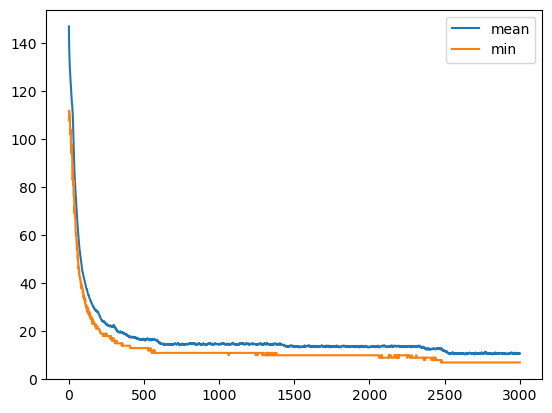

In [33]:
mean, minimum = logbook.select("mean", "min")

fig, ax = plt.subplots()

ax.plot(range(NGEN+1), mean, label="mean")     # 0.tá generace zvlášť
ax.plot(range(NGEN+1), minimum, label="min")
ax.legend()